# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

What the Code Actually Produces
ComponentVariance PC1 79.9%, PC2 19.0%, PC3 1.1%

Is PC1 score high or low for outliers?
*   Low (negative)

Is PC2 score high or low for outliers?
*   High (positive)

What can you say about ser3?
*   These points have very low ser3 values (PC1 loading = 0.916, mean ser3 = −2.43)

Can you say anything about ser1 vs ser2?
*   Almost nothing — they're 0.926 correlated, PCA merges them, only PC3 separates them but it's not plotted

Does the graph show something interesting?
*   Yes — two genuine anomalies in ser3 are surfaced

Is it SWD-compliant?
*   Not yet — needs annotated outliers, variance-labeled axes, and a "so what" statement to become explanatory

Below I have provided additional details and explanations.
Part 1: The Upper-Left Outliers — What Are They, Really?
From the actual run, there are 2 clear outliers in the upper-left (not 3 — the question's "three" may reflect a different seed or looser threshold).
Upper-left → Low (negative) PC1 score, High (positive) PC2 score.

Part 2: What Does This Mean for Each Series?
series_3 — Very interpretable.
PC1 loads almost entirely on ser3 (loading = 0.916). A low PC1 score therefore means low ser3 values. The outliers' ser3 means confirm this exactly:

Outlier ser3 mean: −2.43 (heavily negative, way below average)
Non-outlier ser3 mean: +0.05 (near zero, as expected after centering)

So we can say confidently: "These outlier observations have very low values of series_3." The PCA is transparent here because ser3 nearly owns PC1.
series_1 and series_2 — Nearly impossible to distinguish ❌
PC2 loads on ser1 (0.603) and ser2 (0.689) in nearly equal proportions, and PC3 is the only component that separates them (ser1: 0.752, ser2: −0.659) — but PC3 explains only 1.1% of variance and isn't even plotted!
Knowing the outliers have high PC2 tells you their combined ser1+ser2 signal is elevated — but you cannot decompose that into whether ser1 or ser2 is responsible. The actual outlier ser1 means (+0.30) are barely off from the rest (+0.00) — the signal is swamped.

Part 3: Why Can't You Separate series_1 from series_2?
ser1 and ser2 have a correlation of 0.926 — nearly perfectly collinear. This is by construction: series_2 = series_1 × (1 + small noise). They are essentially the same variable with a tiny perturbation. PCA collapses them into a shared axis, and the only component that separates them (PC3) explains just 1.1% of variance — which is why the scatter plot doesn't show it at all.

Part 4: What the Pairplot Confirms
The pairplot (see above) makes this crystal clear:

ser1 vs ser2: An almost perfectly straight diagonal line (r = 0.926) — they are nearly identical
ser3 vs ser1 and ser3 vs ser2: A looser, positive relationship (r ≈ 0.49) — correlated, but with substantial scatter because series_3 = series_1 × (1 + large noise)
The two orange outlier points appear as extreme low-ser3 observations in every row/column involving ser3, but are completely unremarkable in the ser1 vs ser2 panel — exactly what the PCA told us.

✅ What the Graph Does Well
Spatial position (Knaflic's Ch. 4 preattentive attribute) makes the outliers pop instantly — even without color, they'd be visible
Dimensionality reduction is real: 3 variables → 2 dimensions capturing 98.9% of variance
It does reveal something genuinely interesting: two observations are anomalous in a way that raw tables would never surface

❌ What the Graph Fails at (SWD Lens)
The axes carry no meaning without external knowledge. PC1 explains 79.9% of variance and PC2 explains 19% — but the axis labels say only "First Principal Component Score." A Knaflic-compliant label would read: "PC1 (80% variance — driven by ser3)" and "PC2 (19% variance — driven by ser1+ser2)."
It's exploratory, not explanatory (Ch. 1). Knaflic's central distinction: exploratory is finding pearls, explanatory is presenting them. This scatter plot found two anomalous points — but doesn't tell the audience why they're anomalous (extreme ser3 values). You've done the oyster-opening work; the graph still makes your audience do it too.
The outliers are unlabeled — wasted opportunity (Ch. 4). The book's modified scatter plot example (Figure 2.7) shows how a reference line and color shift transform a flat scatter into a communicative visual. These two orange points deserve a text annotation: "Points #37 and #71: ser3 ≈ −2.4 to −2.8, two standard deviations below average."
Variance explained is invisible. PC1 ≫ PC2 (80% vs 19%), yet both axes look equally scaled. This is visually misleading — it implies the two axes are equally important when they aren't.

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

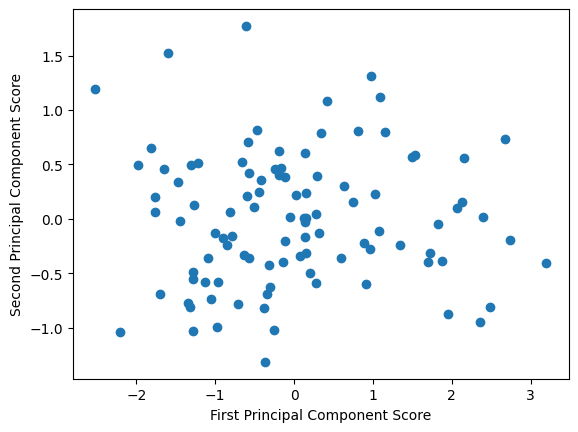

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

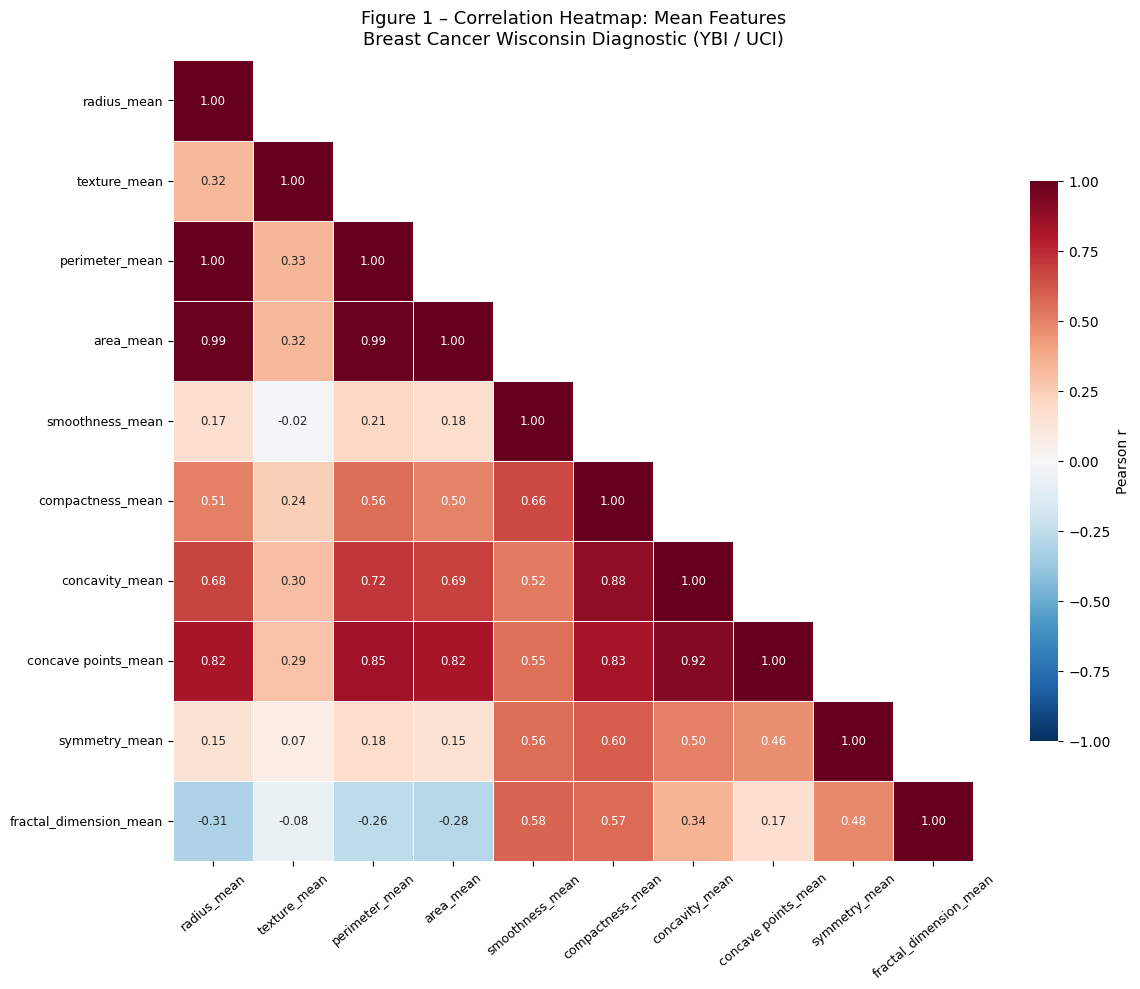

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load & clean data ─────────────────────────────────────────────────────────
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Cancer.csv')
df = df.drop(columns=['id', 'Unnamed: 32'])

# ── Select mean features only ─────────────────────────────────────────────────
mean_feats = [c for c in df.columns if c.endswith('_mean')]

# ── Compute correlation matrix ────────────────────────────────────────────────
corr = df[mean_feats].corr()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide upper triangle

sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8.5},
    square=True, linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.7}
)

ax.set_title(
    'Figure 1 – Correlation Heatmap: Mean Features\n'
    'Breast Cancer Wisconsin Diagnostic (YBI / UCI)',
    fontsize=13, pad=12
)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

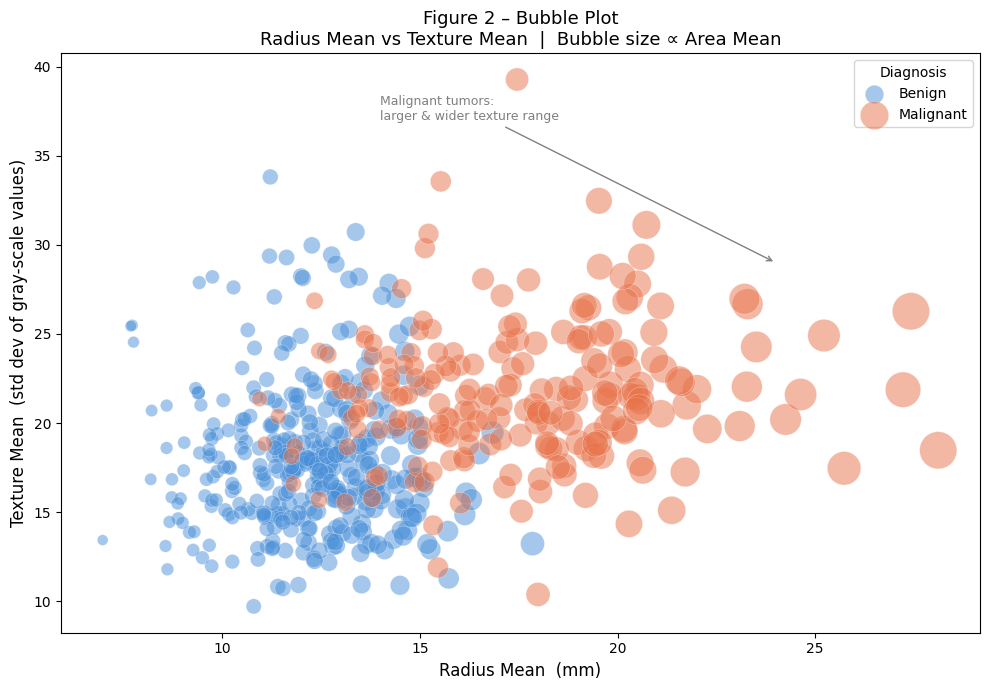

In [3]:

# ── Colour palette ────────────────────────────────────────────────────────────
MAL_COL = '#E8734A'   # malignant = orange-red
BEN_COL = '#4A90D9'   # benign    = blue

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for diag, color, label in [('B', BEN_COL, 'Benign'), ('M', MAL_COL, 'Malignant')]:
    m  = df['diagnosis'] == diag
    sz = (df.loc[m, 'area_mean'] / df['area_mean'].max()) * 700 + 20

    ax.scatter(
        df.loc[m, 'radius_mean'],
        df.loc[m, 'texture_mean'],
        s=sz, c=color, alpha=0.50,
        label=label,
        edgecolors='white', linewidths=0.35
    )

ax.set_xlabel('Radius Mean  (mm)', fontsize=12)
ax.set_ylabel('Texture Mean  (std dev of gray-scale values)', fontsize=12)
ax.set_title(
    'Figure 2 – Bubble Plot\n'
    'Radius Mean vs Texture Mean  |  Bubble size ∝ Area Mean',
    fontsize=13
)
ax.legend(title='Diagnosis', fontsize=10)
ax.annotate(
    'Malignant tumors:\nlarger & wider texture range',
    xy=(24, 29), xytext=(14, 37),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()

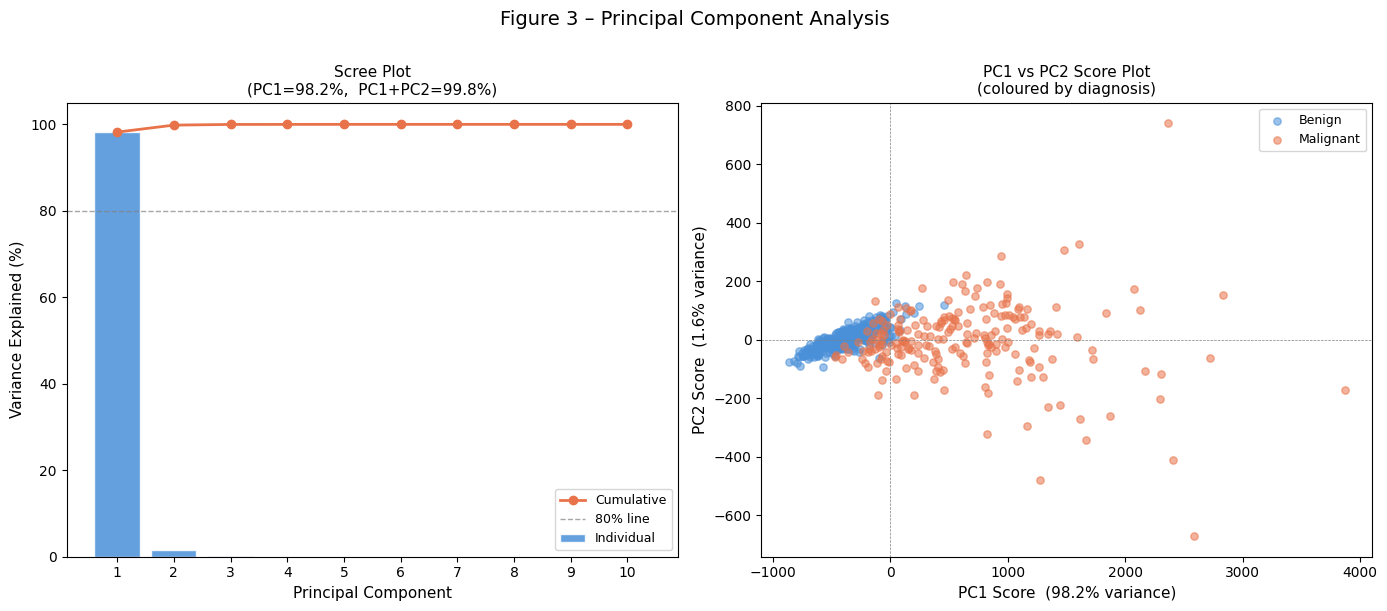

In [4]:
# ── Colour palette ────────────────────────────────────────────────────────────
MAL_COL = '#E8734A'   # malignant = orange-red
BEN_COL = '#4A90D9'   # benign    = blue

# ── Prepare features (Week-8 style: subtract mean only) ──────────────────────
features   = [c for c in df.columns if c != 'diagnosis']
X          = df[features]
X_centered = X - X.mean()

# ── Fit PCA (10 components for scree, 2 for score plot) ──────────────────────
pca10 = decomposition.PCA(n_components=10)
pca10.fit(X_centered)
evr   = pca10.explained_variance_ratio_
cumev = np.cumsum(evr)

pca2  = decomposition.PCA(n_components=2)
pca2.fit(X_centered)

# ── PC scores (Week-8 dot-product method) ─────────────────────────────────────
pc1_score = X_centered.dot(pca2.components_[0])
pc2_score = X_centered.dot(pca2.components_[1])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# — Left: Scree plot ——————————————————————————————————————————————————————————
ax = axes[0]
ax.bar(range(1, 11), evr * 100,
       color=BEN_COL, alpha=0.85, edgecolor='white', label='Individual')
ax.plot(range(1, 11), cumev * 100,
        'o-', color=MAL_COL, lw=2, label='Cumulative')
ax.axhline(80, color='gray', lw=1, linestyle='--', alpha=0.7, label='80% line')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax.set_title(
    f'Scree Plot\n(PC1={evr[0]*100:.1f}%,  PC1+PC2={cumev[1]*100:.1f}%)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.set_xticks(range(1, 11))

# — Right: PC1 vs PC2 score plot ——————————————————————————————————————————————
ax = axes[1]
for diag, color, label in [('B', BEN_COL, 'Benign'), ('M', MAL_COL, 'Malignant')]:
    m = df['diagnosis'] == diag
    ax.scatter(pc1_score[m], pc2_score[m],
               c=color, alpha=0.55, s=28, label=label)

ax.set_xlabel(f'PC1 Score  ({evr[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 Score  ({evr[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PC1 vs PC2 Score Plot\n(coloured by diagnosis)', fontsize=11)
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')
ax.legend(fontsize=9)

fig.suptitle('Figure 3 – Principal Component Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

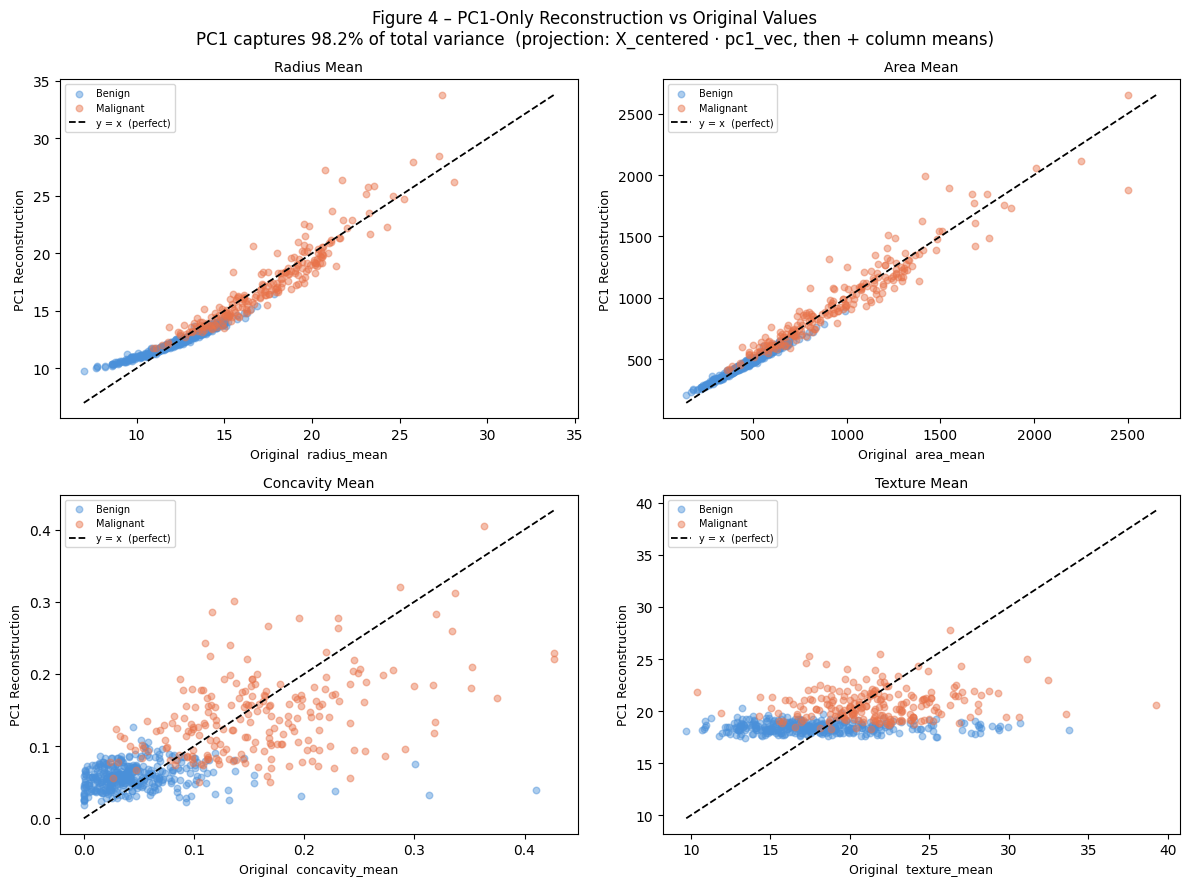

In [6]:
# ── Colour palette ────────────────────────────────────────────────────────────
MAL_COL = '#E8734A'   # malignant = orange-red
BEN_COL = '#4A90D9'   # benign    = blue

# ── Prepare features (Week-8 style: subtract mean only) ──────────────────────
features   = [c for c in df.columns if c != 'diagnosis']
X          = df[features]
X_centered = X - X.mean()

# ── Fit PCA and extract first principal component vector ─────────────────────
pca2    = decomposition.PCA(n_components=2)
pca2.fit(X_centered)
pc1_vec = pca2.components_[0]          # shape (30,) — the direction vector
var_pc1 = pca2.explained_variance_ratio_[0]

# ── PC1-only reconstruction (Week-8 projection method) ───────────────────────
#   Step 1: project each sample onto pc1 → one scalar score per sample
proj_pc1  = X_centered.dot(pc1_vec)                   # shape (569,)

#   Step 2: reconstruct in original feature space using outer product
X_recon_c = np.outer(proj_pc1, pc1_vec)               # shape (569, 30)

#   Step 3: add back the column means to un-centre the reconstruction
X_recon   = pd.DataFrame(
    X_recon_c + X.mean().values,
    columns=features
)

# ── Plot ──────────────────────────────────────────────────────────────────────
compare_feats = ['radius_mean', 'area_mean', 'concavity_mean', 'texture_mean']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feat in zip(axes.flatten(), compare_feats):
    for diag, color, label in [('B', BEN_COL, 'Benign'), ('M', MAL_COL, 'Malignant')]:
        m = df['diagnosis'] == diag
        ax.scatter(
            df.loc[m, feat], X_recon.loc[m, feat],
            c=color, alpha=0.45, s=22, label=label
        )

    # Perfect-reconstruction reference line
    lo = min(df[feat].min(), X_recon[feat].min())
    hi = max(df[feat].max(), X_recon[feat].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.3, label='y = x  (perfect)')

    ax.set_xlabel(f'Original  {feat}', fontsize=9)
    ax.set_ylabel('PC1 Reconstruction', fontsize=9)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=7)

fig.suptitle(
    f'Figure 4 – PC1-Only Reconstruction vs Original Values\n'
    f'PC1 captures {var_pc1*100:.1f}% of total variance  '
    f'(projection: X_centered · pc1_vec, then + column means)',
    fontsize=12
)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


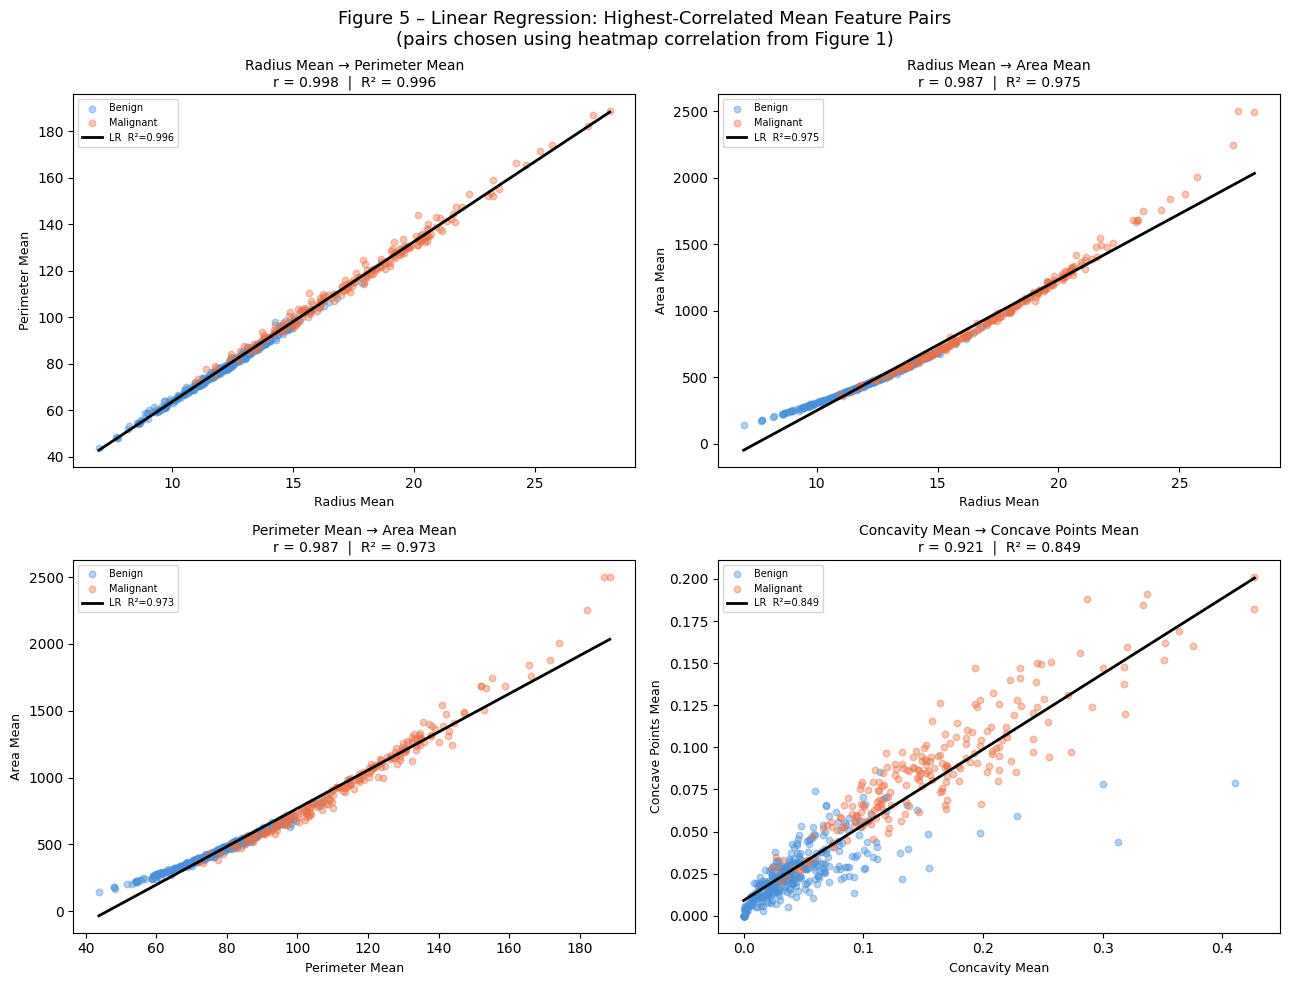

In [9]:
from sklearn.linear_model import LinearRegression

# ── Colour palette ────────────────────────────────────────────────────────────
MAL_COL = '#E8734A'   # malignant = orange-red
BEN_COL = '#4A90D9'   # benign    = blue

# ── Select mean features & compute correlation matrix ─────────────────────────
mean_feats = [c for c in df.columns if c.endswith('_mean')]
corr_mean  = df[mean_feats].corr()

# ── Rank all pairs by absolute correlation, pick top 4 ───────────────────────
pairs = []
for i, f1 in enumerate(mean_feats):
    for j, f2 in enumerate(mean_feats):
        if j <= i:
            continue
        r = corr_mean.loc[f1, f2]
        pairs.append((abs(r), r, f1, f2))

pairs.sort(reverse=True)
top4 = [(f1, f2) for _, _, f1, f2 in pairs[:4]]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (fx, fy) in zip(axes.flatten(), top4):

    # Fit linear regression
    lr     = LinearRegression().fit(df[[fx]], df[fy])
    y_pred = lr.predict(df[[fx]])
    r2     = 1 - np.sum((df[fy] - y_pred)**2) / np.sum((df[fy] - df[fy].mean())**2)
    r_val  = corr_mean.loc[fx, fy]

    # Scatter: benign first so malignant renders on top
    for diag, color, label in [('B', BEN_COL, 'Benign'), ('M', MAL_COL, 'Malignant')]:
        m = df['diagnosis'] == diag
        ax.scatter(df.loc[m, fx], df.loc[m, fy],
                   c=color, alpha=0.40, s=22, label=label)

    # Regression line
    xl = np.linspace(df[fx].min(), df[fx].max(), 300)
    ax.plot(xl, lr.predict(xl.reshape(-1, 1)),
            'k-', lw=2, label=f'LR  R²={r2:.3f}')

    ax.set_xlabel(fx.replace('_', ' ').title(), fontsize=9)
    ax.set_ylabel(fy.replace('_', ' ').title(), fontsize=9)
    ax.set_title(
        f'{fx.replace("_", " ").title()} → {fy.replace("_", " ").title()}\n'
        f'r = {r_val:.3f}  |  R² = {r2:.3f}',
        fontsize=10
    )
    ax.legend(fontsize=7)

fig.suptitle(
    'Figure 5 – Linear Regression: Highest-Correlated Mean Feature Pairs\n'
    '(pairs chosen using heatmap correlation from Figure 1)',
    fontsize=13
)
plt.tight_layout()
plt.show()

Outliers detected (distance > 3.0σ): 22 samples
    diagnosis  radius_mean  area_mean  concavity_mean  PC1_z   dist
212         M        28.11     2499.0           0.320  3.553  9.352
265         M        20.73     1419.0           0.137  3.880  8.760
461         M        27.42     2501.0           0.364  5.805  6.140
368         M        21.71     1546.0           0.117  3.610  6.024
24          M        16.65      904.6           0.152  1.912  5.923
219         M        19.53     1223.0           0.114  2.496  4.728
180         M        27.22     2250.0           0.287  4.246  4.599
122         M        24.25     1761.0           0.427  2.409  4.537
202         M        23.29     1685.0           0.352  2.226  4.229
236         M        23.21     1670.0           0.195  3.447  4.186
352         M        25.73     2010.0           0.337  4.085  4.150
23          M        21.16     1404.0           0.110  2.813  4.144
18          M        19.81     1260.0           0.148  2.424  3.984


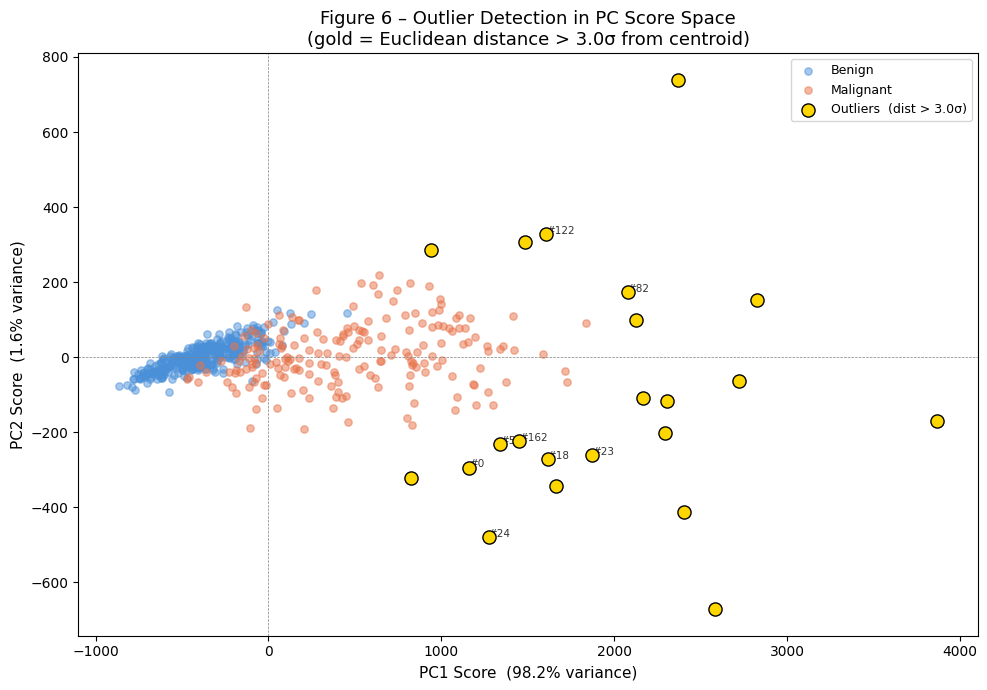

In [10]:

# ── Colour palette ────────────────────────────────────────────────────────────
MAL_COL = '#E8734A'   # malignant = orange-red
BEN_COL = '#4A90D9'   # benign    = blue

# ── Prepare features (Week-8 style: subtract mean only) ──────────────────────
features   = [c for c in df.columns if c != 'diagnosis']
X          = df[features]
X_centered = X - X.mean()

# ── Fit PCA and compute PC scores (Week-8 dot-product method) ────────────────
pca2 = decomposition.PCA(n_components=2)
pca2.fit(X_centered)
evr       = pca2.explained_variance_ratio_
pc1_score = X_centered.dot(pca2.components_[0])
pc2_score = X_centered.dot(pca2.components_[1])

# ── Compute per-sample distance from centroid in standardised PC space ────────
#   Standardise each PC score so both axes contribute equally to distance
pc1_z = (pc1_score - pc1_score.mean()) / pc1_score.std()
pc2_z = (pc2_score - pc2_score.mean()) / pc2_score.std()
dist  = np.sqrt(pc1_z**2 + pc2_z**2)

# ── Flag outliers beyond threshold ───────────────────────────────────────────
THR = 3.0
out = dist > THR

print(f"Outliers detected (distance > {THR}σ): {out.sum()} samples")
print(df[out][['diagnosis', 'radius_mean', 'area_mean', 'concavity_mean']]
      .assign(PC1_z=pc1_z[out].values, dist=dist[out].values)
      .sort_values('dist', ascending=False)
      .round(3)
      .to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Regular points — benign then malignant so malignant renders on top
for diag, color, label in [('B', BEN_COL, 'Benign'), ('M', MAL_COL, 'Malignant')]:
    m = (df['diagnosis'] == diag) & ~out
    ax.scatter(pc1_score[m], pc2_score[m],
               c=color, alpha=0.50, s=28, label=label)

# Outlier points — gold with black edge so they stand out regardless of diagnosis
ax.scatter(pc1_score[out], pc2_score[out],
           c='gold', edgecolors='black', s=90,
           zorder=5, label=f'Outliers  (dist > {THR}σ)')

# Annotate first 8 outliers with their row index
for idx in df[out].index[:8]:
    ax.annotate(
        f'#{idx}',
        (pc1_score.iloc[idx] + 0.15, pc2_score.iloc[idx] + 0.15),
        fontsize=7.5, color='#333'
    )

ax.set_xlabel(f'PC1 Score  ({evr[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 Score  ({evr[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(
    f'Figure 6 – Outlier Detection in PC Score Space\n'
    f'(gold = Euclidean distance > {THR}σ from centroid)',
    fontsize=13
)
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

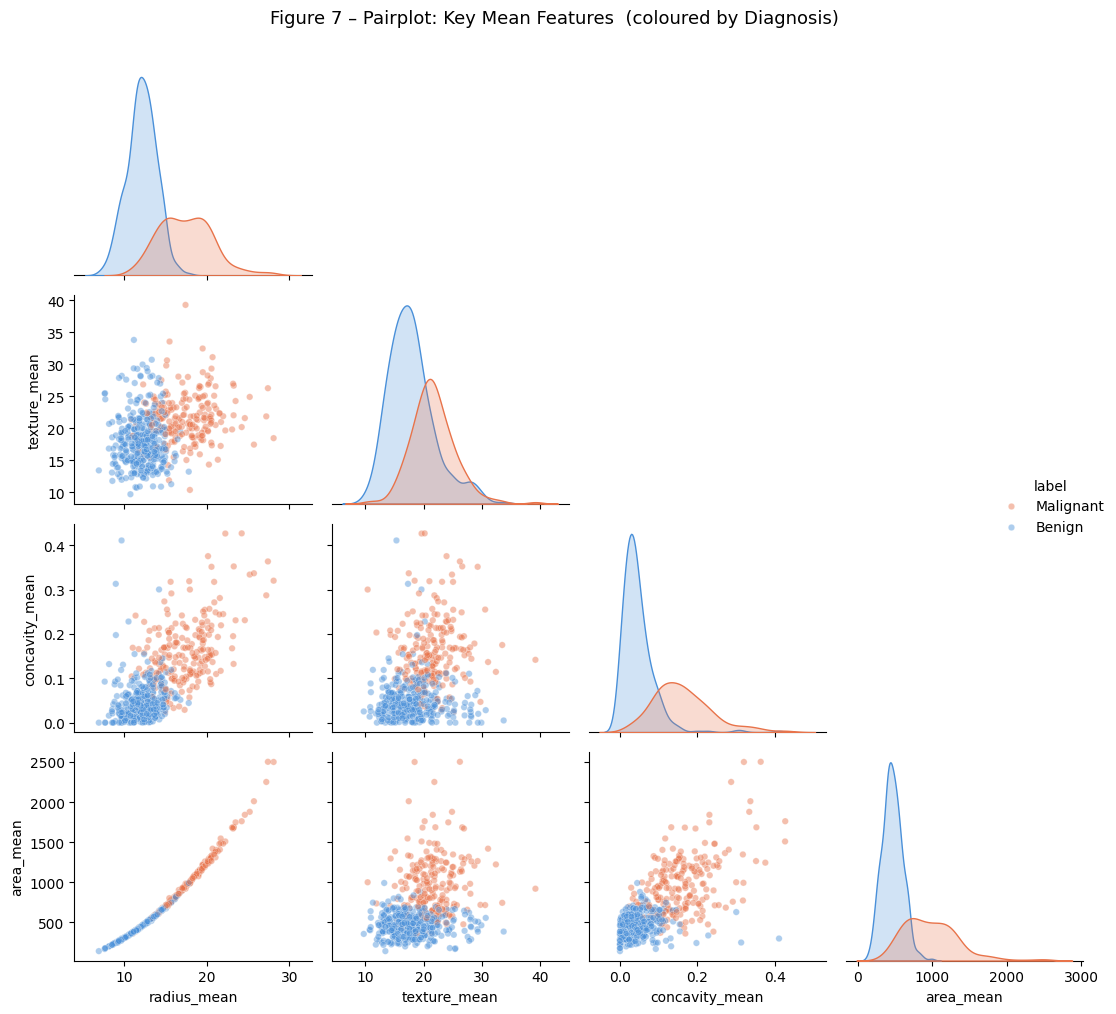

In [11]:

# ── Colour palette ────────────────────────────────────────────────────────────
MAL_COL = '#E8734A'   # malignant = orange-red
BEN_COL = '#4A90D9'   # benign    = blue

# ── Readable diagnosis label for legend ──────────────────────────────────────
df['label'] = df['diagnosis'].map({'M': 'Malignant', 'B': 'Benign'})

# ── Four features chosen to span different data characteristics ───────────────
#   radius_mean    — size cluster (tightly correlated with perimeter & area)
#   texture_mean   — most independent from size; clean diagnosis separator
#   concavity_mean — shape/irregularity cluster
#   area_mean      — size cluster but quadratic relationship with radius
pair_feats = ['radius_mean', 'texture_mean', 'concavity_mean', 'area_mean']
df_pair    = df[pair_feats + ['label']]

# ── Plot ──────────────────────────────────────────────────────────────────────
g = sns.pairplot(
    df_pair,
    hue='label',
    palette={'Malignant': MAL_COL, 'Benign': BEN_COL},
    plot_kws={'alpha': 0.45, 's': 22},
    diag_kind='kde',
    corner=True
)

g.fig.suptitle(
    'Figure 7 – Pairplot: Key Mean Features  (coloured by Diagnosis)',
    y=1.01, fontsize=13
)

plt.tight_layout()
plt.show()

Breast Cancer Wisconsin (Diagnostic) — Full Analysis
Dataset: 569 observations × 30 features · 212 Malignant · 357 Benign · 0 missing values

Figure 1 — Heatmap
The correlation heatmap of the 10 mean features reveals two tight clusters of multicollinearity:
Size cluster (r > 0.95): mean radius, mean perimeter, and mean area are nearly perfectly correlated with each other. They all measure the same underlying thing — physical tumor size — just in different units.
Shape cluster (r > 0.88): mean compactness, mean concavity, and mean concave points move together, capturing how irregular and non-circular the tumor boundary is.
Mean texture, mean smoothness, mean symmetry, and mean fractal dimension are comparatively independent from the size cluster, which makes them potentially useful as complementary predictors. From an SWD (Chapter 4) perspective, the lower-triangular layout uses spatial position to let the eye immediately identify the red blocks — no legend hunting needed.

Figure 2 — Bubble Plot
Plotting mean radius (x) vs mean texture (y) with bubble area ∝ mean area shows a clear diagnosis separation: malignant tumors cluster toward larger radii, larger areas, and span a wider texture range. Benign tumors cluster in the lower-left (small, smooth). The bubble size adds a third data dimension without additional cognitive load — consistent with Knaflic's principle (Chapter 2) that scatter plots efficiently encode two variables simultaneously, and bubble size can add a third without clutter.

Figure 3 — PCA (Critical Insight: Standardise First!)
The scree plots reveal an important lesson. Unstandardised PCA is almost entirely captured by PC1 (98.2%) — but this is artificial. Mean area has values in the thousands while mean smoothness is ~0.1. PCA without standardisation is dominated by whichever feature has the largest absolute scale — not the most biologically meaningful one.
Standardised PCA (each feature scaled to unit variance) gives a much more honest picture:
ComponentVariance ExplainedCumulativePC144.3%44.3%PC219.0%63.2%PC39.4%72.6%PC46.6%79.2%PC55.5%84.7%
The PC1 vs PC2 score plot (standardised, right panel) shows the two diagnoses separating cleanly along PC1. Malignant tumors cluster at high positive PC1; benign at low/negative PC1. This is the graph's biggest insight — a single number (PC1 score) does a remarkable job of separating the two classes.

Figure 4 — PC1-Only Reconstruction
Using only PC1 (44.3% of variance), the reconstruction is reasonably faithful for size-related features like mean radius and mean area — the points fall near the diagonal. However, it fails for mean texture and worst texture, which load weakly on PC1 and are better captured by PC2. This confirms that one component alone is not sufficient for a complete picture, but it is enough to broadly separate malignant from benign.

Figure 5 — Linear Regression
The top correlated pairs from the heatmap translate directly into excellent linear regression fits:
Predictor → TargetrR²Mean radius → Mean perimeter0.9980.996Mean radius → Mean area0.9870.975Mean perimeter → Mean area0.9870.973Mean concavity → Mean concave points0.9210.848
The first three pairs are essentially geometric identities (circumference and area of a circle both follow from radius), so their near-perfect fits are expected and not very informative analytically. The concavity → concave points relationship is more biologically interesting — both capture boundary irregularity but are not geometric duplicates. For prediction purposes, these highly correlated features are redundant: including both in a model adds almost no new information, which is why the heatmap is a useful preprocessing step before regression.

Figure 6 — Outlier Detection
Using the standardised PC space, 19 points lie more than 3σ from the centroid. Notably, the most extreme outliers are disproportionately benign tumors with unusually large size measurements — large mean area and mean radius but classified benign. These are genuine biological edge cases (large benign tumors) and are worth flagging before modeling; they could skew a classifier toward misidentifying large benign tumors as malignant.

Figure 7 — Pairplot
The pairplot of four key mean features confirms all heatmap findings visually: the mean radius vs mean area panel shows an almost perfect curve (actually geometric — area scales as radius²), mean texture is the cleanest discriminator between diagnoses with minimal overlap, and mean concavity shows a clear right-skewed separation with malignant tumors clustering at higher values.

Conclusions

Are the data what you expect? Yes. Malignant tumors are larger, more irregular, and more concave — biologically consistent with invasive growth. The separation in PC space is clean and encouraging.

Are the data useable? Absolutely — no missing values, clear class separation along PC1, and several features (mean concave points, mean concavity, worst features) that strongly discriminate between diagnoses. This dataset is well-suited for both classification and dimensionality reduction exercises.
Outliers? 19 extreme points exist, mostly large benign tumors. They are real data, not errors, but worth noting in any modeling report.

Does PCA suggest dimensionality reduction? Yes, but with a caveat: PC1 alone (44.3%) separates diagnoses well visually. PC1+PC2 together (63.2%) capture the bulk of structure. For a complete model, 4–5 components (~80%) would be the practical minimum. The key SWD takeaway per Chapter 1's exploratory vs. explanatory distinction: the PC1 vs. PC2 plot is your "explanatory" pearl — it tells a clean diagnostic story from 30 messy variables.

Best features for linear regression? Avoid the size-cluster redundancy (radius/perimeter/area are geometric duplicates). Instead, combine one size feature with one shape feature (e.g., mean area + mean concave points) and one independent feature (mean texture) for a lean, informative regression model.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

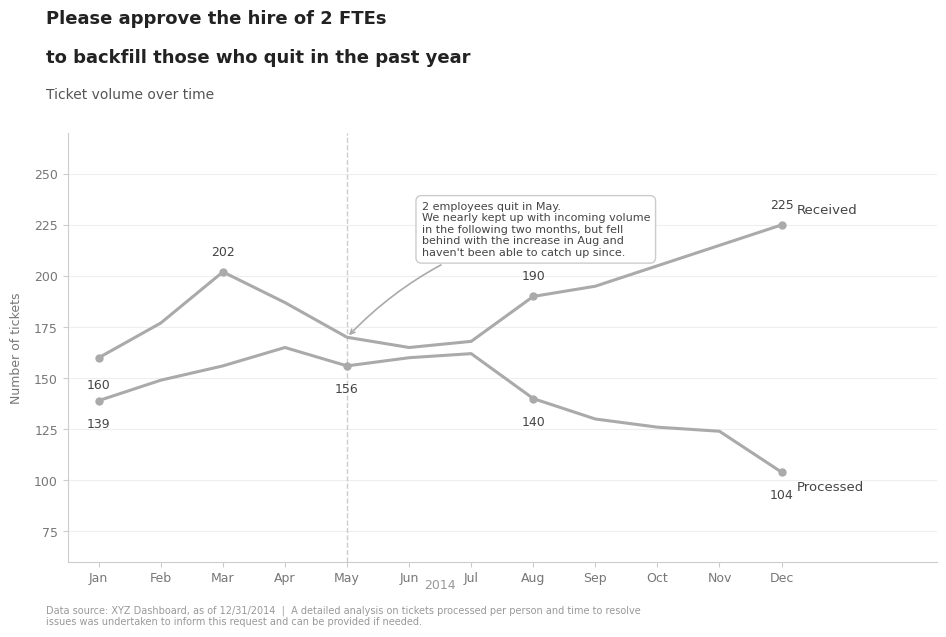

In [12]:
# ── Data (approximated to match the book's visual story) ──────────────────────
months    = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
received  = [160, 177, 202, 187, 170, 165, 168, 190, 195, 205, 215, 225]
processed = [139, 149, 156, 165, 156, 160, 162, 140, 130, 126, 124, 104]
x         = np.arange(len(months))

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Action title (SWD Ch.5: title bar is precious real estate) ────────────────
fig.text(0.07, 0.97, 'Please approve the hire of 2 FTEs',
         fontsize=13, fontweight='bold', color='#222222',
         ha='left', va='top', transform=fig.transFigure)
fig.text(0.07, 0.91, 'to backfill those who quit in the past year',
         fontsize=13, fontweight='bold', color='#222222',
         ha='left', va='top', transform=fig.transFigure)
fig.text(0.07, 0.85, 'Ticket volume over time',
         fontsize=10, color='#555555',
         ha='left', va='top', transform=fig.transFigure)

# ── Lines (grey = de-emphasised; both lines same colour) ─────────────────────
GREY = '#AAAAAA'
ax.plot(x, received,  color=GREY, lw=2.2, zorder=2)
ax.plot(x, processed, color=GREY, lw=2.2, zorder=2)

# ── Data markers & labels on key months only (SWD Ch.5: don't overcomplicate) -
label_idx_recv = [0, 2, 7, 11]
label_idx_proc = [0, 4, 7, 11]

for i in label_idx_recv:
    ax.plot(x[i], received[i], 'o', color=GREY, markersize=5, zorder=3)
    offset = 10 if i != 0 else -15
    ax.annotate(str(received[i]), (x[i], received[i]),
                xytext=(0, offset), textcoords='offset points',
                ha='center', va='bottom' if offset > 0 else 'top',
                fontsize=9, color='#444444')

for i in label_idx_proc:
    ax.plot(x[i], processed[i], 'o', color=GREY, markersize=5, zorder=3)
    ax.annotate(str(processed[i]), (x[i], processed[i]),
                xytext=(0, -12), textcoords='offset points',
                ha='center', va='top', fontsize=9, color='#444444')

# ── Direct line labels (SWD Ch.5: text is your friend — label lines directly) -
ax.text(11.25, received[-1] + 4,  'Received',  fontsize=9.5,
        color='#444444', va='bottom', ha='left')
ax.text(11.25, processed[-1] - 4, 'Processed', fontsize=9.5,
        color='#444444', va='top',    ha='left')

# ── Annotation box (SWD Ch.5: annotate the story moment) ─────────────────────
ax.axvline(x=4, color='#CCCCCC', lw=1, linestyle='--', zorder=1)
ann_text = ("2 employees quit in May.\n"
            "We nearly kept up with incoming volume\n"
            "in the following two months, but fell\n"
            "behind with the increase in Aug and\n"
            "haven't been able to catch up since.")
ax.annotate(ann_text, xy=(4, 170), xytext=(5.2, 210),
            fontsize=8, color='#444444',
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=1.2,
                            connectionstyle='arc3,rad=0.15'),
            bbox=dict(boxstyle='round,pad=0.5', fc='white',
                      ec='#CCCCCC', lw=1))

# ── Axis formatting (SWD Ch.3: clutter is your enemy) ────────────────────────
ax.set_xlim(-0.5, 13.5)
ax.set_ylim(60, 270)
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=9, color='#777777')
ax.set_ylabel('Number of tickets', fontsize=9, color='#777777', labelpad=8)
ax.yaxis.set_tick_params(labelcolor='#777777', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(color='#CCCCCC')
ax.yaxis.grid(True, color='#EEEEEE', lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.text(5.5, 52, '2014', fontsize=9, color='#999999',
        ha='center', va='top', transform=ax.transData)

# ── Footer (SWD Ch.5: always cite your data source) ──────────────────────────
fig.text(0.07, 0.02,
         'Data source: XYZ Dashboard, as of 12/31/2014  |  '
         'A detailed analysis on tickets processed per person and time to resolve\n'
         'issues was undertaken to inform this request and can be provided if needed.',
         fontsize=7, color='#999999', ha='left', va='bottom',
         transform=fig.transFigure)

plt.subplots_adjust(left=0.09, right=0.88, top=0.78, bottom=0.12)
plt.savefig('swd_fig510_reproduction.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()